# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Customer Shopping Behavior Dataset](https://www.kaggle.com/datasets/ankitrajmishra/customer-shopping-behaviour-analysis)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/ankitrajmishra/customer-shopping-behaviour-analysis/customer_shopping_behavior.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('customer_shopping_behavior.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


## last Five row

In [4]:
df.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
5045,913,24,Male,Hoodie,Clothing,56.0,Arkansas,M,Green,Winter,3.4,Yes,Next Day Air,Yes,32.0,Bank Transfer,Monthly
5046,3466,19,Female,Backpack,Accessories,53.0,Iowa,M,Gold,Spring,3.4,No,Standard,No,31.0,Debit Card,Weekly
5047,3572,70,Female,Skirt,Clothing,27.0,North Dakota,M,White,Summer,3.2,No,Standard,No,15.0,Bank Transfer,Every 3 Months
5048,3195,43,Female,Sneakers,Footwear,52.0,Maryland,L,Gold,Summer,4.6,No,Standard,No,10.0,Credit Card,Bi-Weekly
5049,1832,62,Male,Blouse,Clothing,71.0,Maine,M,Cyan,Summer,3.3,No,Free Shipping,No,5.0,Bank Transfer,Every 3 Months


## Shape of our dataset

In [5]:
df.shape

(5050, 17)

## List out all columns

In [6]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)     float64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Previous Purchases        float64
Payment Method             object
Frequency of Purchases     object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   object 
 3   Item Purchased          5050 non-null   object 
 4   Category                5050 non-null   object 
 5   Purchase Amount (USD)   4494 non-null   float64
 6   Location                5050 non-null   object 
 7   Size                    4680 non-null   object 
 8   Color                   5050 non-null   object 
 9   Season                  5050 non-null   object 
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   object 
 12  Shipping Type           5050 non-null   object 
 13  Discount Applied        5050 non-null   object 
 14  Previous Purchases      4502 non-null   

## Check Null Value

In [9]:
df.isnull().sum()

Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)     556
Location                    0
Size                      370
Color                       0
Season                      0
Review Rating             601
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases        548
Payment Method              0
Frequency of Purchases      0
dtype: int64

## drop all columns that have any null values

In [10]:
df = df.dropna(axis=1)

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(50)

## Summary

In [12]:
df.describe()

,Customer ID,Age
count,5050.000000,5050.000000
mean,2519.570891,44.150495
std,1470.402964,15.282328
min,1.000000,18.000000
25%,1252.250000,31.000000
50%,2499.500000,44.000000
75%,3740.750000,57.000000
max,5099.000000,70.000000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

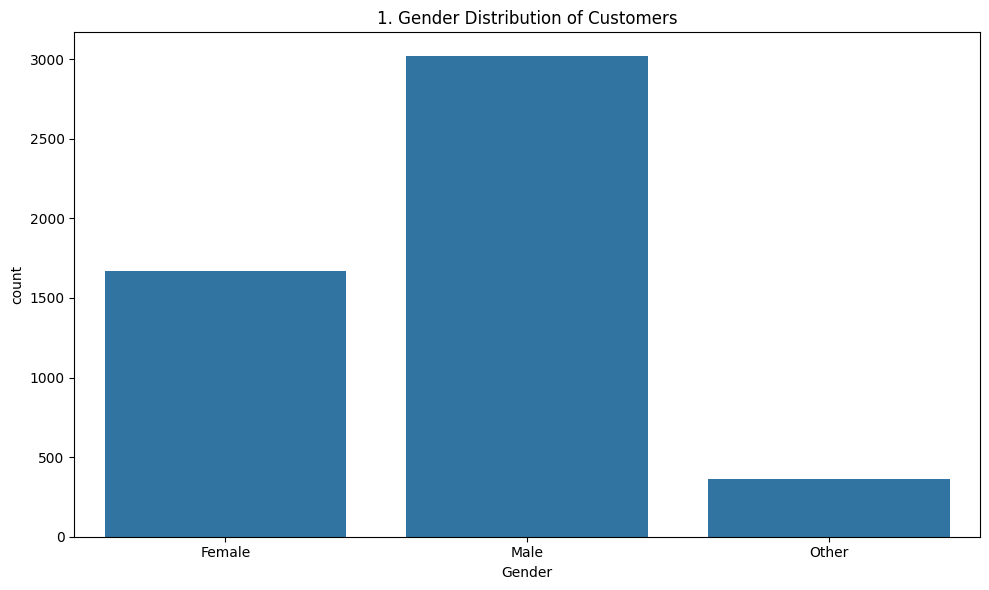

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title(f'{plot_no}. Gender Distribution of Customers')
show_fig()
plot_no += 1

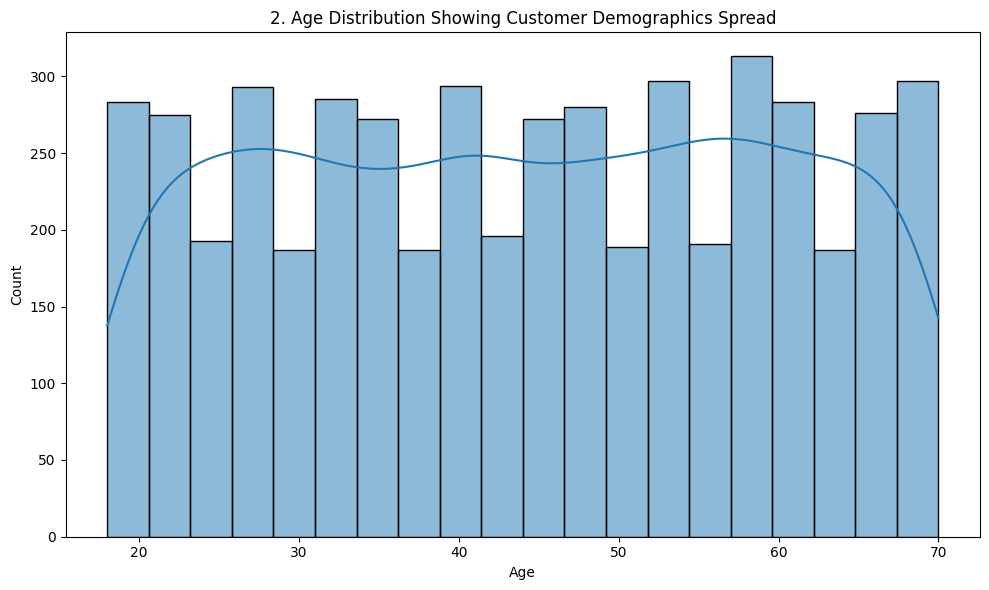

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution Showing Customer Demographics Spread')
show_fig()
plot_no += 1

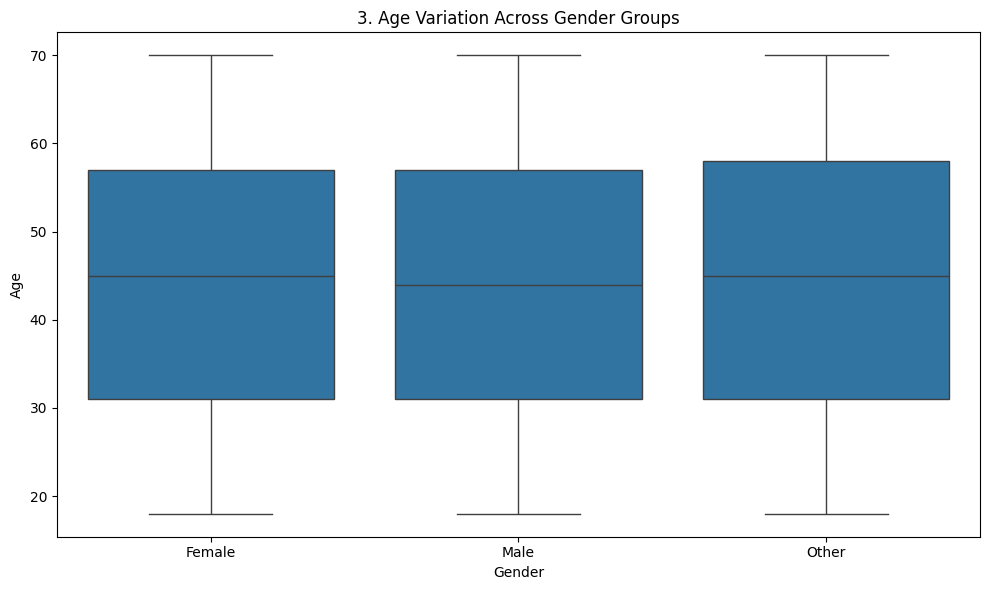

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='Gender', y='Age', data=df)
plt.title(f'{plot_no}. Age Variation Across Gender Groups')
show_fig()
plot_no += 1

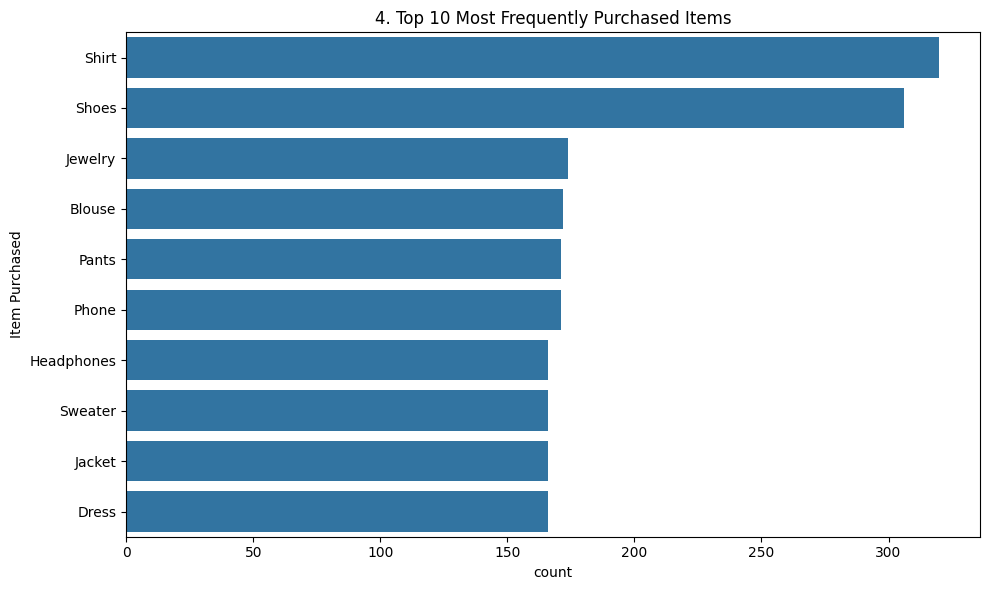

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Item Purchased', data=df, order=df['Item Purchased'].value_counts().head(10).index)
plt.title(f'{plot_no}. Top 10 Most Frequently Purchased Items')
show_fig()
plot_no += 1

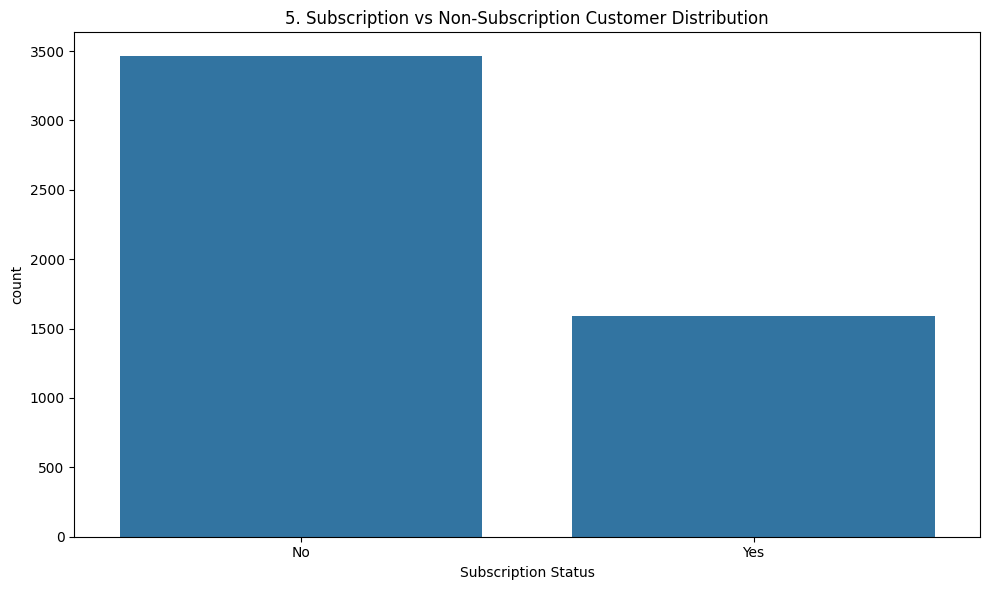

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Subscription Status', data=df)
plt.title(f'{plot_no}. Subscription vs Non-Subscription Customer Distribution')
show_fig()
plot_no += 1

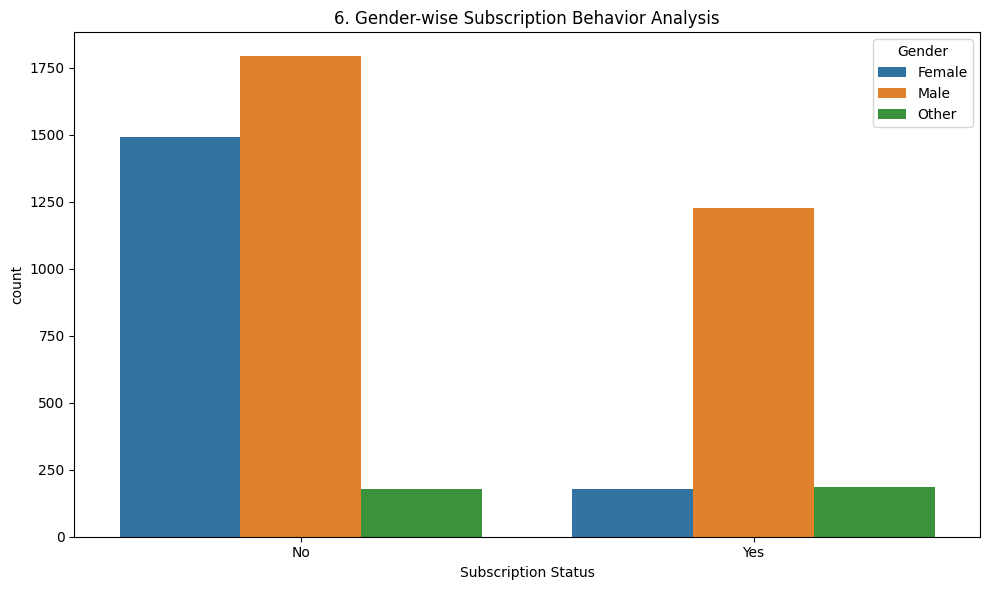

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Subscription Status', hue='Gender', data=df)
plt.title(f'{plot_no}. Gender-wise Subscription Behavior Analysis')
show_fig()
plot_no += 1

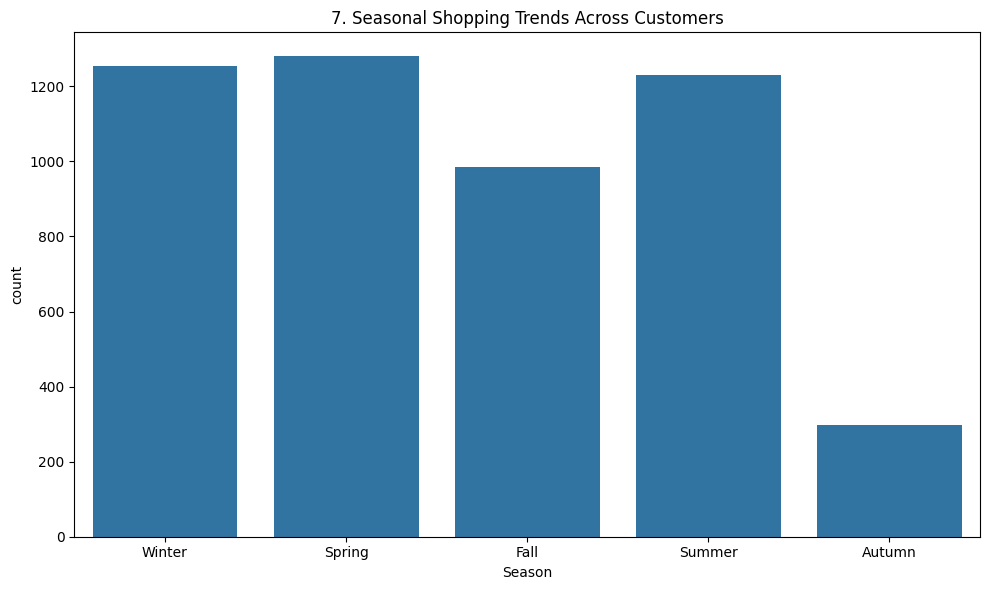

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Season', data=df)
plt.title(f'{plot_no}. Seasonal Shopping Trends Across Customers')
show_fig()
plot_no += 1

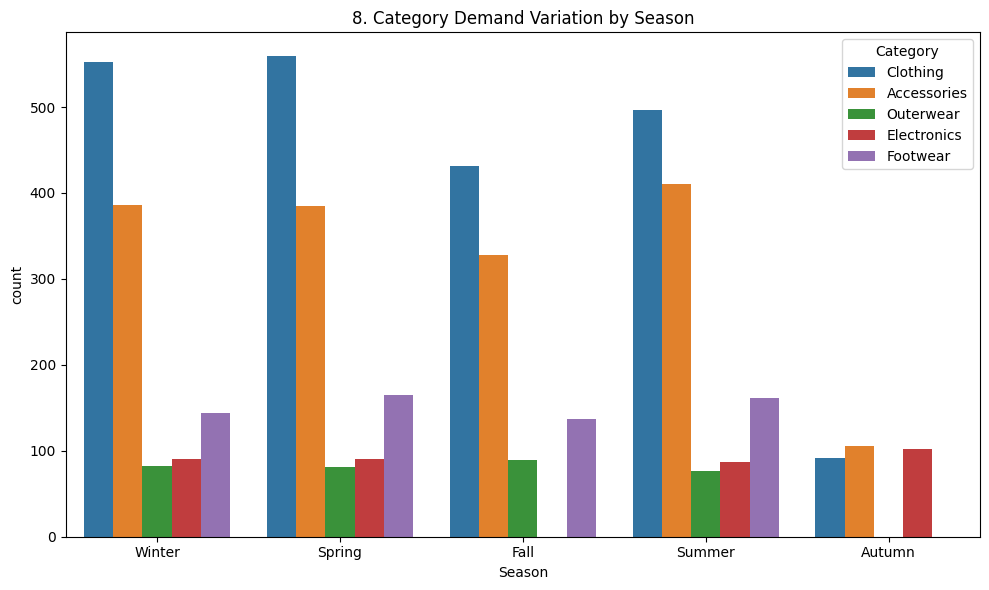

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Season', hue='Category', data=df)
plt.title(f'{plot_no}. Category Demand Variation by Season')
show_fig()
plot_no += 1

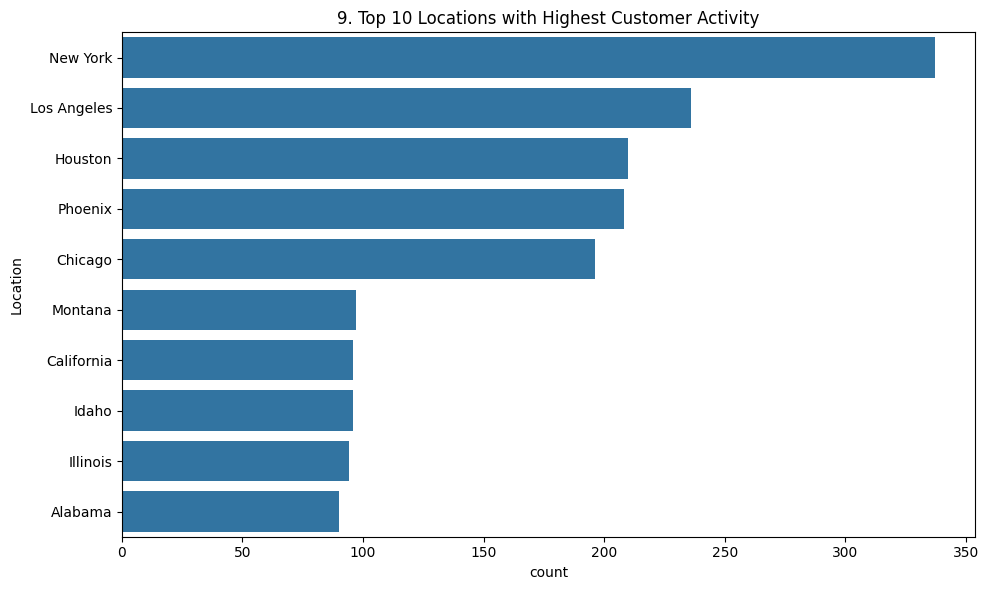

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(y='Location', data=df, order=df['Location'].value_counts().head(10).index)
plt.title(f'{plot_no}. Top 10 Locations with Highest Customer Activity')
show_fig()
plot_no += 1

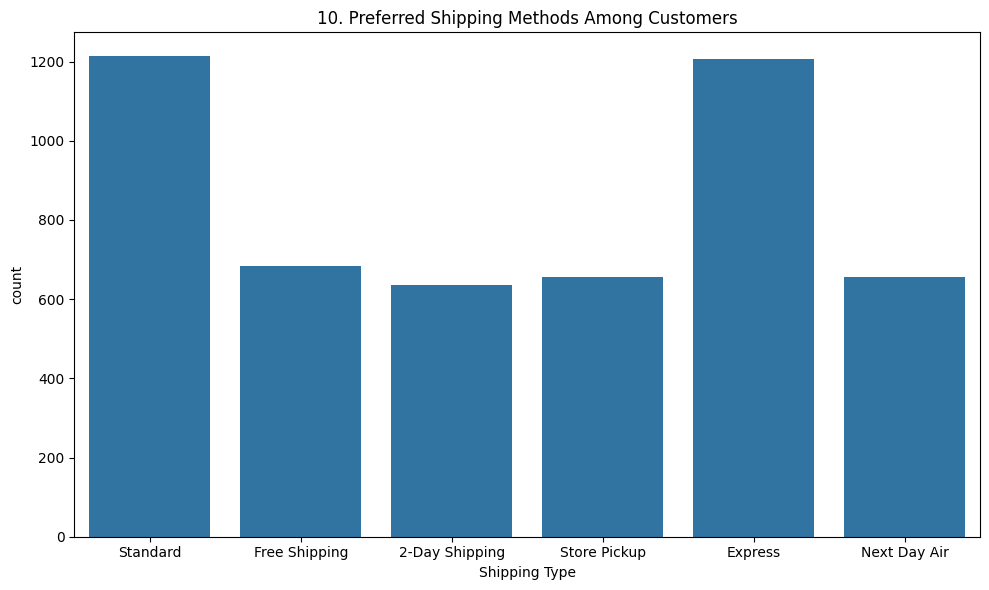

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Shipping Type', data=df)
plt.title(f'{plot_no}. Preferred Shipping Methods Among Customers')
show_fig()
plot_no += 1

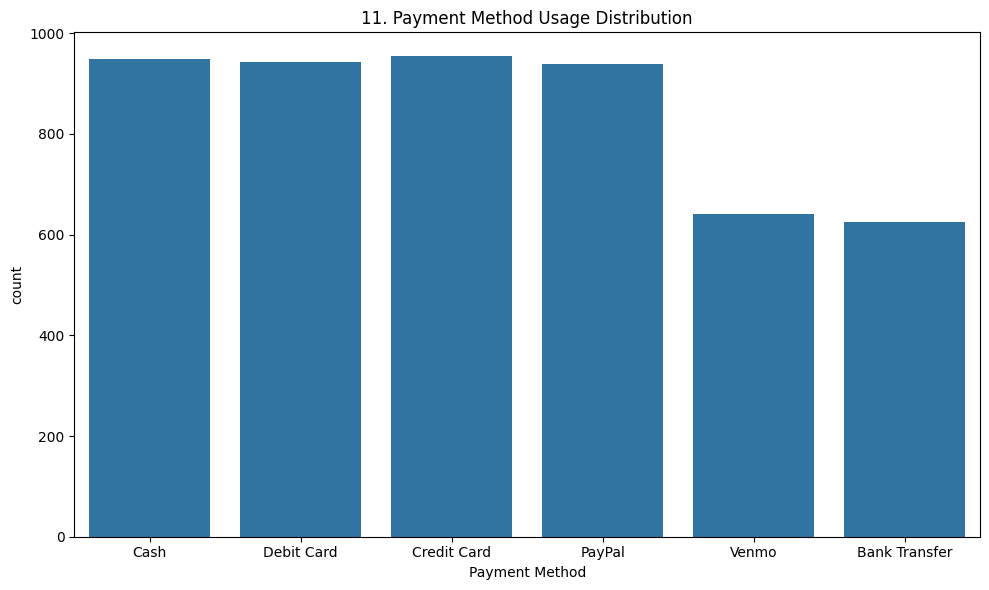

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Payment Method', data=df)
plt.title(f'{plot_no}. Payment Method Usage Distribution')
show_fig()
plot_no += 1

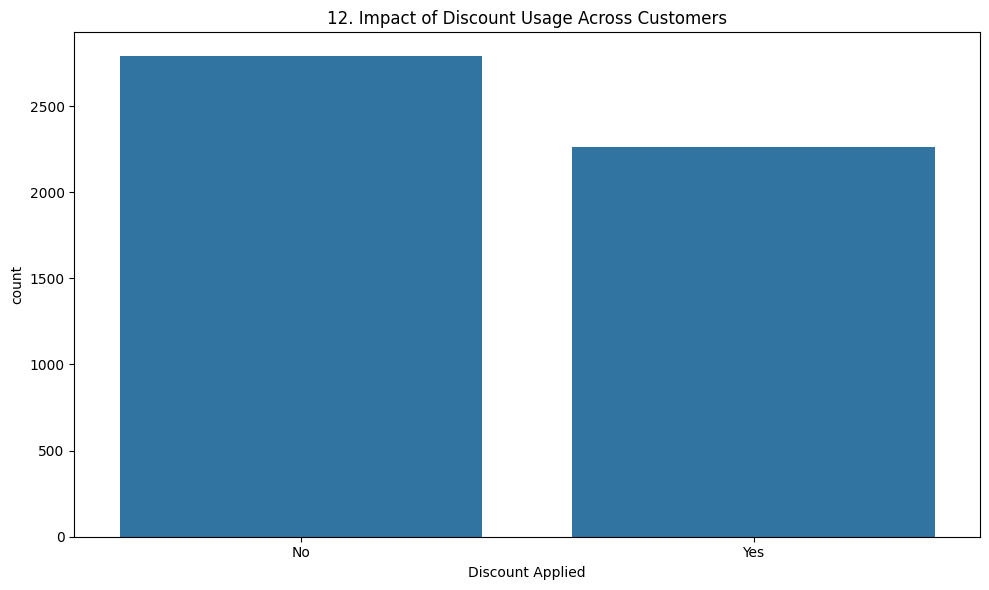

In [25]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Discount Applied', data=df)
plt.title(f'{plot_no}. Impact of Discount Usage Across Customers')
show_fig()
plot_no += 1

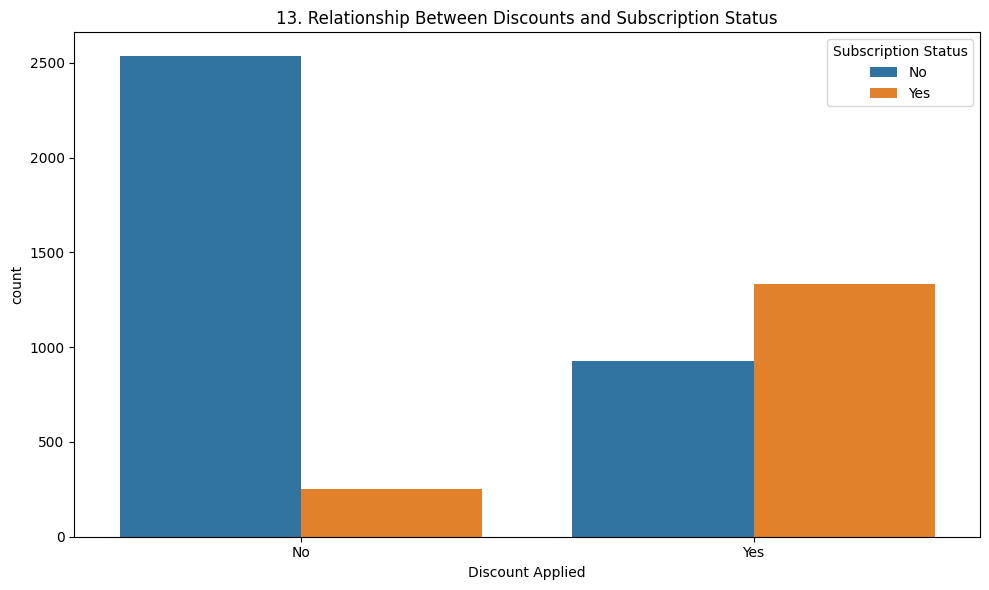

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Discount Applied', hue='Subscription Status', data=df)
plt.title(f'{plot_no}. Relationship Between Discounts and Subscription Status')
show_fig()
plot_no += 1

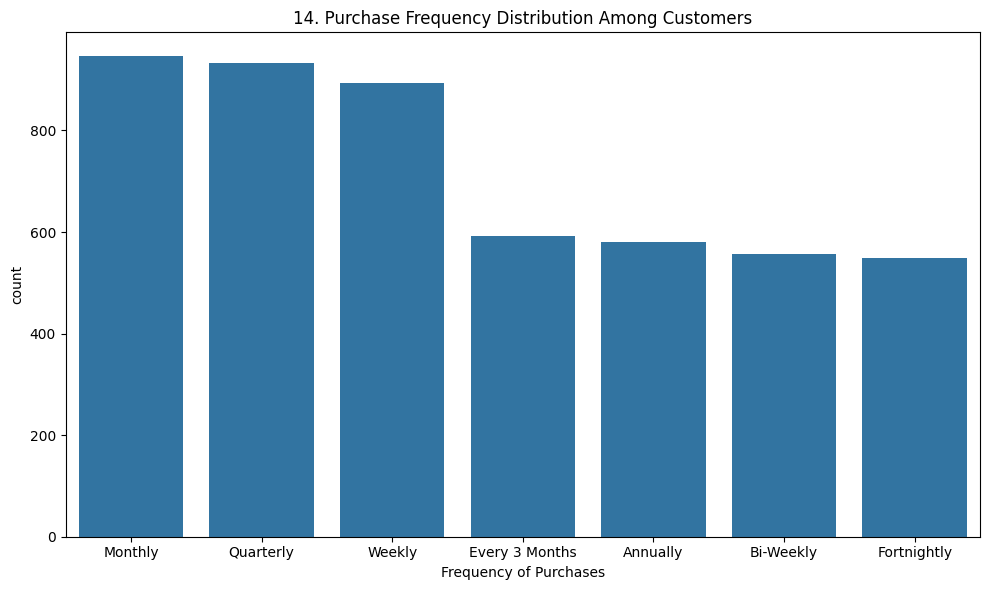

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Frequency of Purchases', data=df, order=df['Frequency of Purchases'].value_counts().index)
plt.title(f'{plot_no}. Purchase Frequency Distribution Among Customers')
show_fig()
plot_no += 1

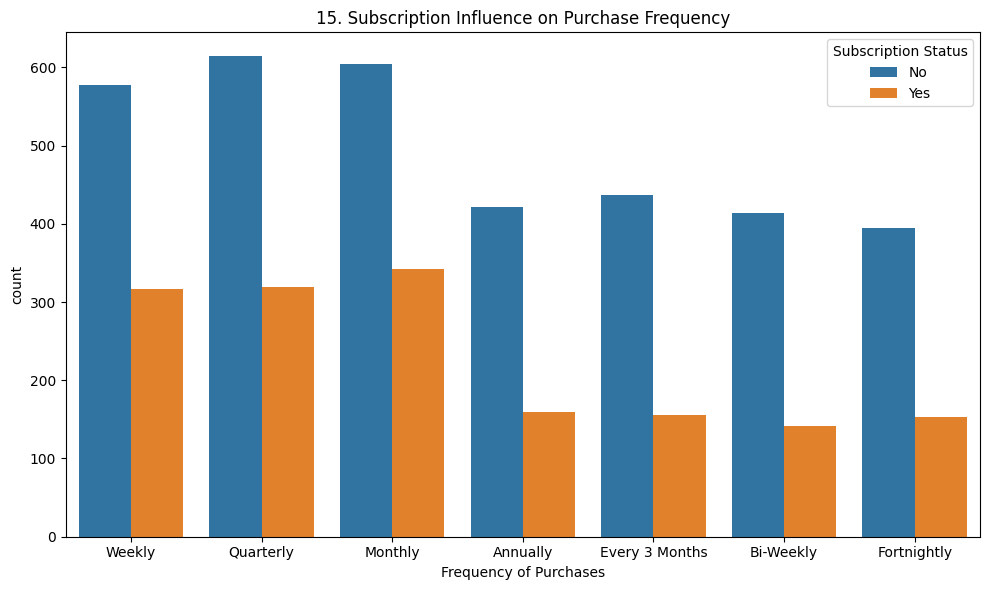

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Frequency of Purchases', hue='Subscription Status', data=df)
plt.title(f'{plot_no}. Subscription Influence on Purchase Frequency')
show_fig()
plot_no += 1

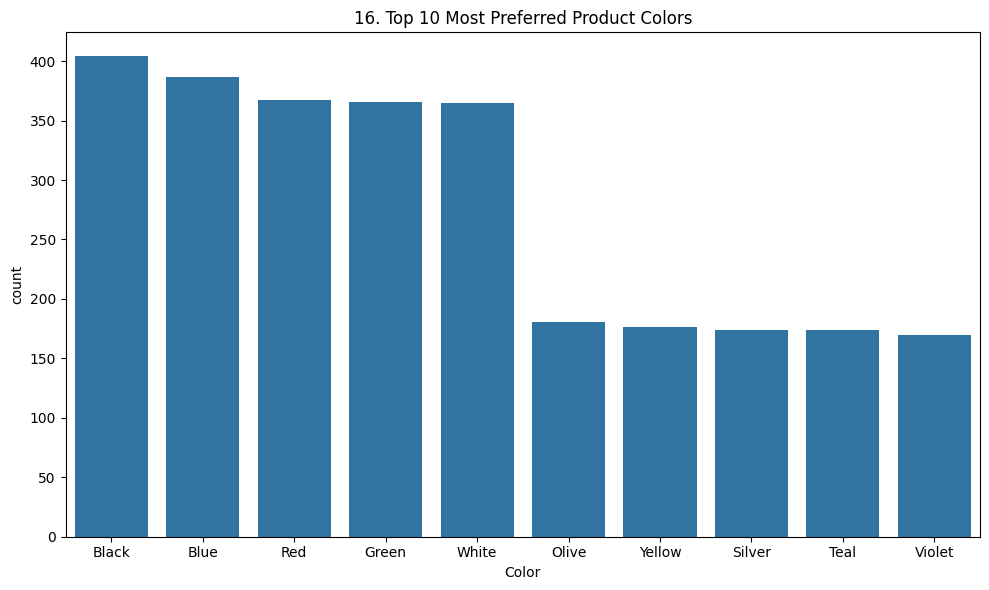

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Color', data=df, order=df['Color'].value_counts().head(10).index)
plt.title(f'{plot_no}. Top 10 Most Preferred Product Colors')
show_fig()
plot_no += 1

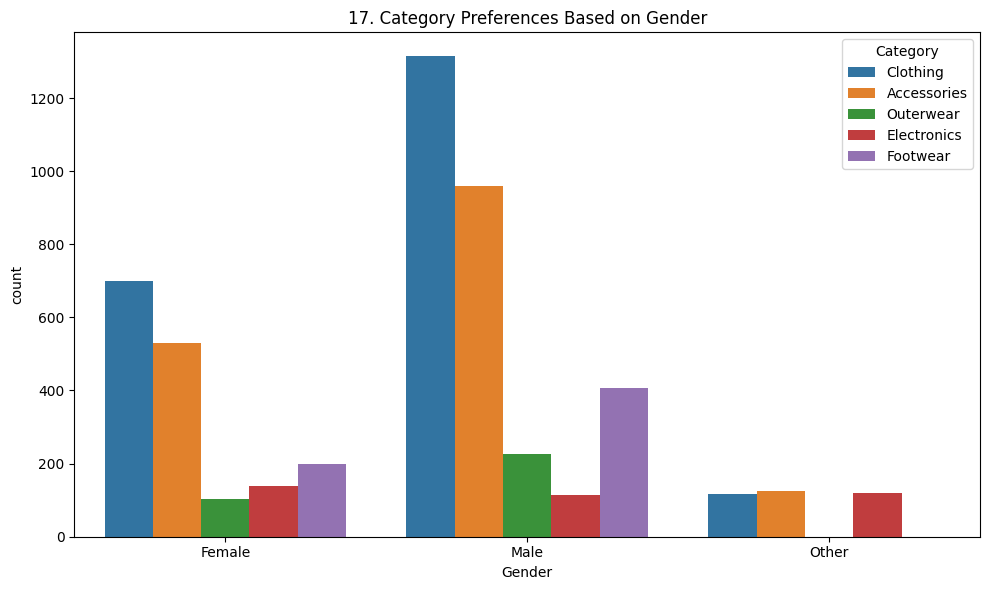

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='Gender', hue='Category', data=df)
plt.title(f'{plot_no}. Category Preferences Based on Gender')
show_fig()
plot_no += 1

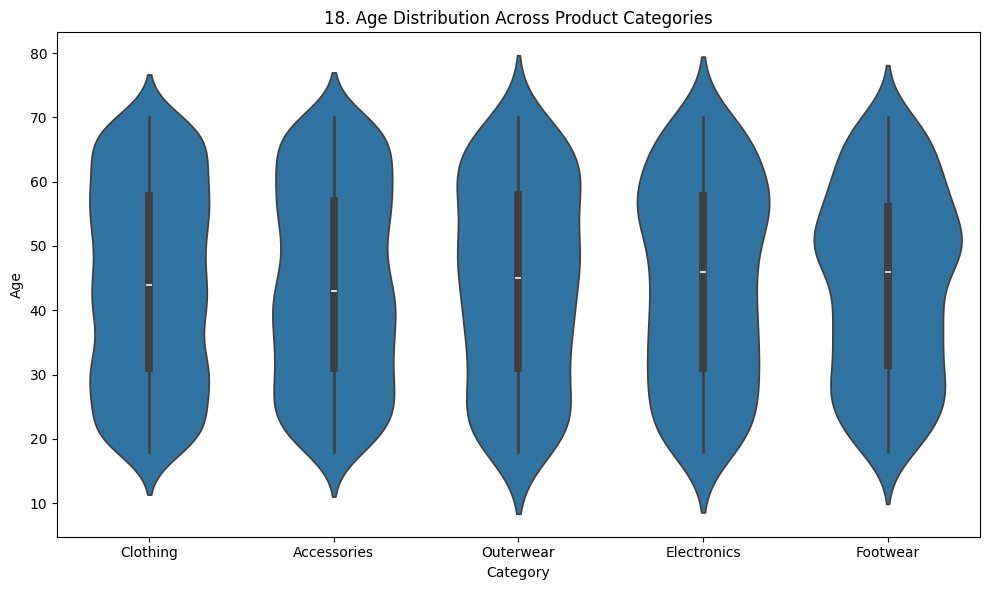

In [31]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='Category', y='Age', data=df)
plt.title(f'{plot_no}. Age Distribution Across Product Categories')
show_fig()
plot_no += 1

# Model Training

## copy dataset

In [32]:
data = df.copy()

## encode categorical variables

In [33]:
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

## define features and target

In [34]:
X = data.drop('Subscription Status', axis=1)
y = data['Subscription Status']

## split dataset

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale features

In [36]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model

In [37]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## make predictions

In [38]:
y_pred = model.predict(X_test)

## print accuracy

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7891089108910891


## plot confusion matrix

<Figure size 1000x600 with 0 Axes>

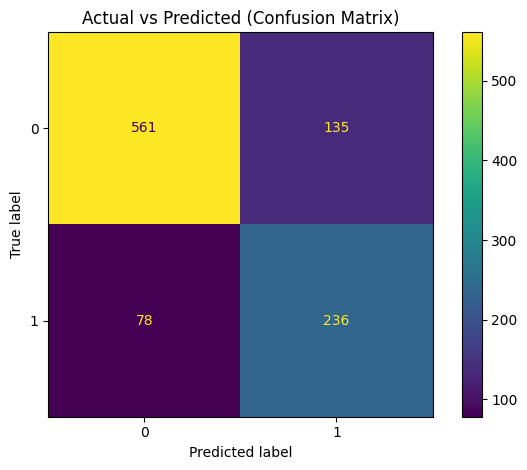

In [40]:
fig = plt.figure(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()